## Project Workflow

The following steps will be carried out in this notebook:

1. **Problem Definition** Define the objective of the project and determine the target variable to be predicted.

2. **Dataset Description** Describe the dataset, including its source, number of observations, and the variables used.

3. **Exploratory Data Analysis (EDA)** Explore the dataset to understand data distribution, relationships between variables, and basic statistics.

4. **Feature Selection** Select relevant variables that will be used as input features for the model.

5. **Data Preprocessing** Prepare the data by handling missing values, ensuring correct data types, and preparing the dataset for modeling.

6. **Model Training** Develop and train the machine learning model using the selected features.

7. **Model Evaluation** Evaluate the model performance using appropriate evaluation metrics.

8. **Time Series Cross Validation (Bonus)** Validate the model's robustness against time-series data using a walk-forward validation approach to prevent data leakage.

9. **Conclusion** Summarize the project results, discuss the influence of the selected features on the target variable, and highlight the project's alignment with SDG 13: Climate Action.

## Step 1 — Problem Definition

**1. Problem Statement & Objective**
This project aims to develop a machine learning model to predict the **average relative humidity (RH_AVG)** using real-world meteorological parameters. The dataset includes variables such as temperature (TAVG), wind speed (FF_AVG), sunshine duration (SS), wind direction (DDD_X), and rainfall (RR). The primary objective is to analyze the underlying relationships between these atmospheric variables and build a predictive regression model that can accurately estimate humidity levels based on daily weather conditions.

**2. Relevance to SDG**
This project strongly aligns with **SDG 13: Climate Action**. Relative humidity is a crucial climate variable that directly affects heat stress, precipitation patterns, and the overall ecosystem. By analyzing historical weather data and developing a robust forecasting model, this project contributes to a deeper understanding of local climate dynamics, which is a vital component for climate monitoring and early warning systems.

**3. Dataset Selection & Justification**
* **Source & Citation:** Indonesian Agency for Meteorology, Climatology, and Geophysics (BMKG) - [Data Online BMKG](https://dataonline.bmkg.go.id/data-harian).
* **Justification:** In strict compliance with the assignment requirements to avoid Kaggle datasets, we sourced authentic, raw daily weather data directly from the official BMKG database. This ensures the data is highly credible, relevant to our local climate context, and provides a unique analytical challenge compared to standard, pre-cleaned toy datasets. 

**4. Methodology & Implementation Logic**
To solve this regression problem, we will build a **Multiple Linear Regression** model optimized via a **Custom Gradient Descent** algorithm. The model will be implemented **entirely from scratch**. No external machine learning libraries (such as `scikit-learn`) or built-in mathematical optimization functions (such as `numpy.polyfit` or `numpy.linalg.lstsq`) will be used. Only basic `NumPy` and `Pandas` libraries are utilized strictly for data manipulation, matrix multiplications, and exploratory analysis.

**Target Variable:** Average Relative Humidity (`RH_AVG`)  
**Problem Type:** Regression

In [1]:
# Import library
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2 — Dataset Description

This project uses a **daily weather dataset from BMKG** (Badan Meteorologi, Klimatologi, dan Geofisika) sourced from their official [Data Online portal](https://dataonline.bmkg.go.id/data-harian). The dataset contains **716 observations** recorded from **01-04-2024 to 18-03-2026**. 

Each row represents the weather conditions recorded for a single day, capturing several key meteorological variables such as:
* **Temperature:** Average (`TAVG`), Minimum (`TN`), Maximum (`TX`)
* **Wind:** Average Speed (`FF_AVG`), Direction (`DDD_X`, `DDD_CAR`)
* **Humidity:** Average Relative Humidity (`RH_AVG`) — *Target Variable*
* **Sunshine:** Sunshine Duration (`SS`)
* **Precipitation:** Rainfall (`RR`)

**Data Collection Source** The data was specifically extracted from the **Stasiun Klimatologi D I Yogyakarta** (Yogyakarta Climatology Station). During the data retrieval process from the BMKG portal, all available daily weather parameters were selected to ensure a comprehensive set of features for building our regression model.

**Raw Data Access** If you would like to inspect the original, unprocessed raw dataset used in this project, it is publicly available in the GitHub repository:  
[🔗 View Raw Dataset on GitHub (AmeliaOchaM/bmkg-humidity-prediction)](https://github.com/AmeliaOchaM/bmkg-humidity-prediction)

### Dataset Preview

To understand the structure of the dataset, the first and last rows of the dataset are displayed below.

In [2]:
# Load dataset
df = pd.read_excel("/kaggle/input/datasets/ameliaochamaharani/fiks-dataset-update-2year/Data_bmkg18_bulan_lengkap.xlsx")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head(5))

print("\nLast 5 rows:")
display(df.tail(5))

Dataset shape: (717, 11)

First 5 rows:


,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
0,2024-04-01,25.4,29.2,27.0,88.0,0.0,3.8,4,250,2,W
1,2024-04-02,24.8,30.3,28.3,85.0,8.7,1.2,5,240,2,W
2,2024-04-03,24.8,32.6,29.7,79.0,1.5,5.6,3,260,2,W
3,2024-04-04,25.4,31.8,29.9,78.0,5.0,8.2,4,260,2,SW
4,2024-04-05,25.0,32.0,29.5,77.0,0.0,9.8,5,250,2,W



Last 5 rows:


,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG,DDD_CAR
712,2026-03-14,22.2,32.3,26.8,81.0,0.0,8.0,6,210,3,SW
713,2026-03-15,23.2,31.4,26.4,84.0,0.0,8.0,6,190,3,NW
714,2026-03-16,22.8,31.6,26.2,86.0,7.2,7.2,5,200,2,W
715,2026-03-17,23.2,31.6,26.9,83.0,12.5,8.0,4,250,2,W
716,2026-03-18,24.1,31.8,27.1,86.0,0.0,8.0,6,250,3,SW


## Step 3 — Exploratory Data Analysis (EDA)

In this step, an initial exploratory data analysis is performed to understand the structure and characteristics of the dataset. This includes examining basic statistics, checking data types, and identifying potential issues such as missing or invalid values.

This analysis helps determine the necessary preprocessing steps before developing the machine learning model.

1. CORRELATION MATRIX (Semua vs Semua)
           TN     TX   TAVG  RH_AVG     RR     SS   FF_X  DDD_X  FF_AVG
TN      1.000  0.190  0.474   0.236 -0.019 -0.106 -0.021 -0.028  -0.054
TX      0.190  1.000  0.640  -0.448 -0.107  0.227  0.091 -0.100   0.037
TAVG    0.474  0.640  1.000  -0.582 -0.119  0.158 -0.037 -0.035   0.069
RH_AVG  0.236 -0.448 -0.582   1.000  0.327 -0.331 -0.065 -0.004  -0.269
RR     -0.019 -0.107 -0.119   0.327  1.000 -0.297 -0.059 -0.006  -0.165
SS     -0.106  0.227  0.158  -0.331 -0.297  1.000  0.040 -0.044   0.101
FF_X   -0.021  0.091 -0.037  -0.065 -0.059  0.040  1.000  0.100   0.559
DDD_X  -0.028 -0.100 -0.035  -0.004 -0.006 -0.044  0.100  1.000   0.162
FF_AVG -0.054  0.037  0.069  -0.269 -0.165  0.101  0.559  0.162   1.000


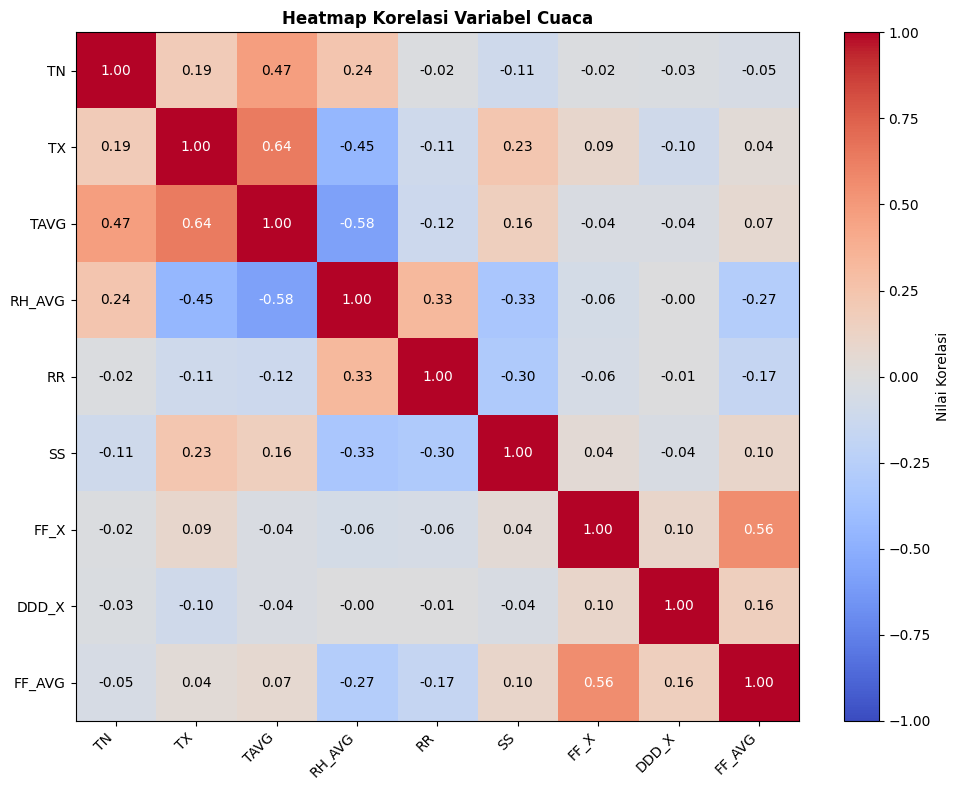


2. KORELASI SEMUA VARIABEL vs RH_AVG
RR        0.327
TN        0.236
DDD_X    -0.004
FF_X     -0.065
FF_AVG   -0.269
SS       -0.331
TX       -0.448
TAVG     -0.582
Name: RH_AVG, dtype: float64


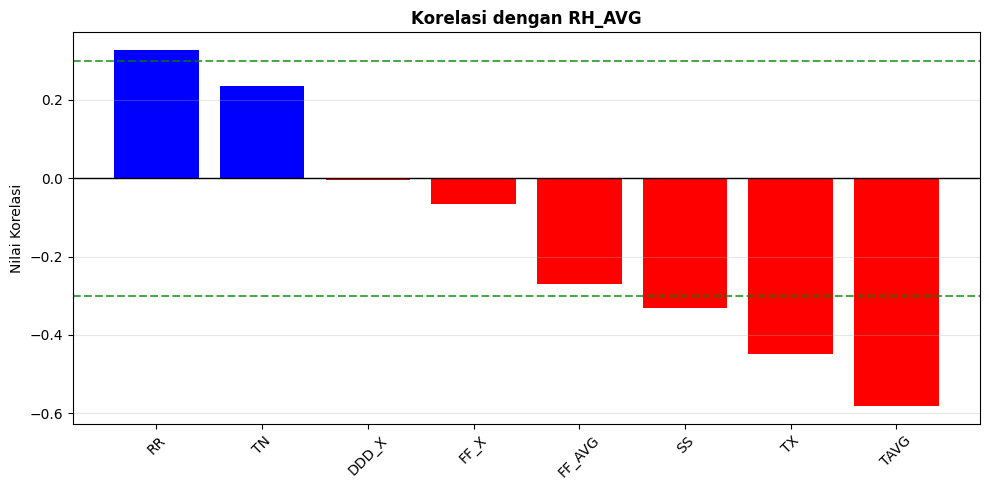

In [3]:
# Pilih kolom numerik
numeric_cols = ['TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'DDD_X', 'FF_AVG']
df_numeric = df[numeric_cols]

# 1. CORRELATION MATRIX (manual dari scratch)
def calculate_correlation_matrix(df):
    """Hitung matriks korelasi dari scratch"""
    cols = df.columns
    n = len(cols)
    corr = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            x = df[cols[i]].dropna()
            y = df[cols[j]].dropna()
            
            # Ambil data yang sama-sama tidak null
            common_idx = x.index.intersection(y.index)
            x_common = x[common_idx]
            y_common = y[common_idx]
            
            if len(x_common) > 1:
                # Hitung korelasi Pearson manual
                x_mean = np.mean(x_common)
                y_mean = np.mean(y_common)
                
                numerator = np.sum((x_common - x_mean) * (y_common - y_mean))
                denominator = np.sqrt(np.sum((x_common - x_mean)**2) * np.sum((y_common - y_mean)**2))
                
                corr[i, j] = numerator / denominator if denominator != 0 else 0
            else:
                corr[i, j] = 0
    
    return pd.DataFrame(corr, index=cols, columns=cols)

# Hitung korelasi
corr_matrix = calculate_correlation_matrix(df_numeric)

print("="*50)
print("1. CORRELATION MATRIX (Semua vs Semua)")
print("="*50)
print(corr_matrix.round(3))

# 2. HEATMAP (manual dengan matplotlib)
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Nilai Korelasi')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Heatmap Korelasi Variabel Cuaca', fontweight='bold')

# Tambah nilai di setiap sel
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', 
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
plt.tight_layout()
plt.show()

# 3. KORELASI SEMUA vs RH_AVG
print("\n" + "="*50)
print("2. KORELASI SEMUA VARIABEL vs RH_AVG")
print("="*50)

corr_with_rh = corr_matrix['RH_AVG'].drop('RH_AVG').sort_values(ascending=False)
print(corr_with_rh.round(3))

# Bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(len(corr_with_rh)), corr_with_rh.values, 
        color=['red' if x < 0 else 'blue' for x in corr_with_rh.values])
plt.axhline(y=0, color='black', linewidth=1)
plt.axhline(y=0.3, color='green', linestyle='--', alpha=0.7)
plt.axhline(y=-0.3, color='green', linestyle='--', alpha=0.7)
plt.xticks(range(len(corr_with_rh)), corr_with_rh.index, rotation=45)
plt.title('Korelasi dengan RH_AVG', fontweight='bold')
plt.ylabel('Nilai Korelasi')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Hitung jumlah data hilang per kolom (menganggap '-', 8888, 9999, dan NaN sebagai missing)
missing_counts = {}
for col in numeric_cols:
    col_series = df[col]
    missing_mask = col_series.isna() | (col_series == "NaN") | (col_series == "nan") | (col_series == 8888) | (col_series == 9999) | (col_series == "-") | (col_series == "") | (col_series == " ") |  col_series.isnull()
    missing_counts[col] = missing_mask.sum()

print("=== MISSING VALUE COUNTS (per column) ===")
for col, cnt in missing_counts.items():
    print(f"{col}: {cnt}")

=== MISSING VALUE COUNTS (per column) ===
TN: 5
TX: 5
TAVG: 1
RH_AVG: 1
RR: 64
SS: 4
FF_X: 0
DDD_X: 0
FF_AVG: 0


## Step 4 — Feature Selection

Feature selection is performed based on the correlation between independent variables and the target variable (RH_AVG), as well as data quality considerations such as missing values.

Based on this analysis, the selected features for predicting RH_AVG are:

TN, TAVG, SS, RR, and FF_AVG

These variables are chosen because they have relatively strong relationships with the target variable and contain minimal missing values, making them more reliable for model training.

## Step 5 — Data Preprocessing

In this step, the dataset is cleaned and prepared before model training. This includes handling missing or invalid values, converting data types, and normalizing numerical features if necessary.

The goal of preprocessing is to ensure that the data is consistent, clean, and suitable for machine learning algorithms.

In [5]:
# ----------------------------------------------------------
# STEP 1: Load & Sort Data
# ----------------------------------------------------------
df = pd.read_excel("/kaggle/input/datasets/ameliaochamaharani/fiks-dataset-update-2year/Data_bmkg18_bulan_lengkap.xlsx", parse_dates=["TANGGAL"])
df = df.sort_values("TANGGAL").set_index("TANGGAL")

# ----------------------------------------------------------
# STEP 2: Drop Kolom Tidak Dipakai
# ----------------------------------------------------------
df = df[["TAVG", "TN", "SS", "FF_AVG", "RR", "RH_AVG"]]

# ----------------------------------------------------------
# STEP 2.5: Tambah Fitur Musiman (Siklis)
# ----------------------------------------------------------
df["bulan_sin"] = np.sin(2 * np.pi * df.index.month / 12)
df["bulan_cos"] = np.cos(2 * np.pi * df.index.month / 12)

# ----------------------------------------------------------
# STEP 3: Drop Baris RH_AVG Kosong
# ----------------------------------------------------------
df = df.dropna(subset=["RH_AVG"])

# ----------------------------------------------------------
# STEP 4: Split Data Sequential (83% train / 17% test)
# ----------------------------------------------------------
split_idx = int(len(df) * 0.83)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

# ----------------------------------------------------------
# STEP 5: Handle Missing Values (median dari train saja)
# ----------------------------------------------------------
median_tavg = train["TAVG"].median()
median_tn   = train["TN"].median()
median_ss   = train["SS"].median()
median_rr   = train["RR"].median()

for d in [train, test]:
    d["TAVG"] = d["TAVG"].fillna(median_tavg)
    d["TN"]   = d["TN"].fillna(median_tn)
    d["SS"]   = d["SS"].fillna(median_ss)
    d["RR"]   = d["RR"].fillna(median_rr)

# ----------------------------------------------------------
# STEP 6: Pisahkan X dan y
# ----------------------------------------------------------
features = ["TAVG", "TN", "SS", "FF_AVG", "RR", "bulan_sin", "bulan_cos"]
target   = "RH_AVG"

X_train = train[features].values
y_train = train[target].values
X_test  = test[features].values
y_test  = test[target].values

# ----------------------------------------------------------
# STEP 7: Feature Scaling Z-score (dari train saja)
# ----------------------------------------------------------
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled  = (X_test  - X_mean) / X_std

# ----------------------------------------------------------
# STEP 8: Tambahkan Bias (kolom 1 di paling kiri)
# ----------------------------------------------------------
bias_train = np.ones((X_train_scaled.shape[0], 1))
bias_test  = np.ones((X_test_scaled.shape[0],  1))

X_train_final = np.hstack([bias_train, X_train_scaled])
X_test_final  = np.hstack([bias_test,  X_test_scaled])

# ----------------------------------------------------------
# SAVE
# ----------------------------------------------------------
save_dir = "preprocessed"
os.makedirs(save_dir, exist_ok=True)

col_names = ["bias", "TAVG", "TN", "SS", "FF_AVG", "RR", "bulan_sin", "bulan_cos"]

train_df = pd.DataFrame(X_train_final, columns=col_names)
train_df["RH_AVG"] = y_train

test_df = pd.DataFrame(X_test_final, columns=col_names)
test_df["RH_AVG"] = y_test

train_path = os.path.join(save_dir, "train.csv")
test_path  = os.path.join(save_dir, "test.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path,  index=False)

# ----------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------
print("Train samples  :", X_train_final.shape[0])
print("Test  samples  :", X_test_final.shape[0])
print("X shape (train):", X_train_final.shape)
print("y shape (train):", y_train.shape)
print("Features       :", col_names)
print("X_mean :", X_mean)
print("X_std  :", X_std)
print(f"\nFile disimpan di:")
print(f"  {train_path}")
print(f"  {test_path}")

Train samples  : 594
Test  samples  : 122
X shape (train): (594, 8)
y shape (train): (594,)
Features       : ['bias', 'TAVG', 'TN', 'SS', 'FF_AVG', 'RR', 'bulan_sin', 'bulan_cos']
X_mean : [26.75723906 23.14983165  5.39208754  1.86195286  6.93703704 -0.11309245
 -0.14282352]
X_std  : [ 1.28368018  1.19819237  2.4915726   0.65735944 16.07051932  0.70161286
  0.68887658]

File disimpan di:
  preprocessed/train.csv
  preprocessed/test.csv


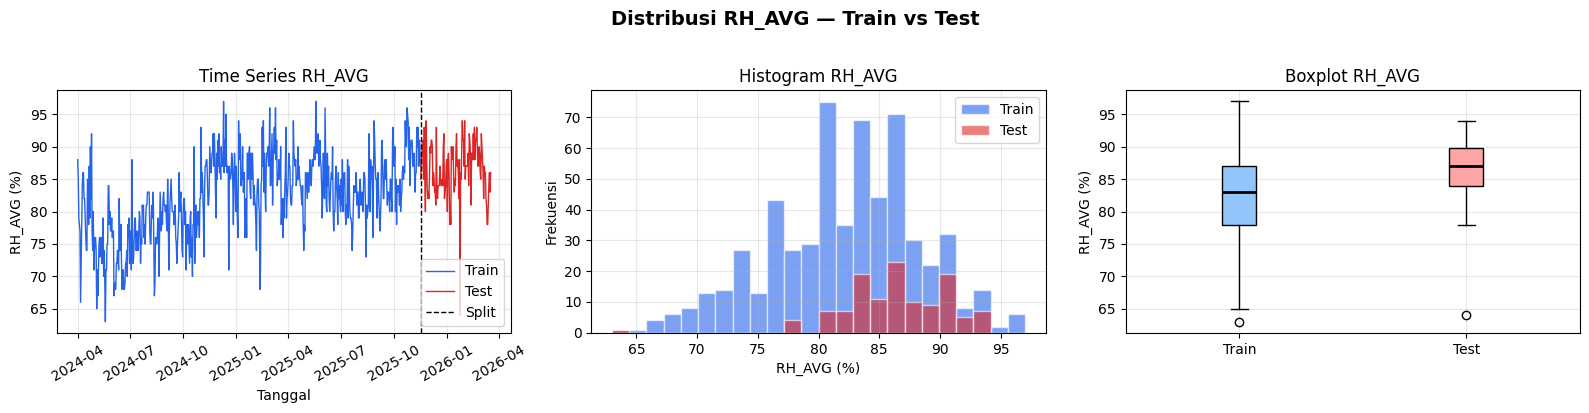

=== STATISTIK RH_AVG ===
Metric            Train       Test
----------------------------------
Count               594        122
Mean              82.14      86.41
Std                6.14       4.27
Min               63.00      64.00
Max               97.00      94.00
Median            83.00      87.00


In [6]:
rh_train = train["RH_AVG"].values
rh_test  = test["RH_AVG"].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribusi RH_AVG — Train vs Test", fontsize=14, fontweight="bold", y=1.02)

# ----------------------------------------------------------
# PLOT 1: Time Series
# ----------------------------------------------------------
axes[0].plot(train.index, rh_train, color="#2563eb", linewidth=1, label="Train")
axes[0].plot(test.index,  rh_test,  color="#dc2626", linewidth=1, label="Test")
axes[0].axvline(test.index[0], color="black", linestyle="--", linewidth=1, label="Split")
axes[0].set_title("Time Series RH_AVG")
axes[0].set_xlabel("Tanggal")
axes[0].set_ylabel("RH_AVG (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=30)

# ----------------------------------------------------------
# PLOT 2: Histogram Overlay
# ----------------------------------------------------------
bins = np.linspace(min(rh_train.min(), rh_test.min()),
                   max(rh_train.max(), rh_test.max()), 25)

axes[1].hist(rh_train, bins=bins, color="#2563eb", alpha=0.6, label="Train", edgecolor="white")
axes[1].hist(rh_test,  bins=bins, color="#dc2626", alpha=0.6, label="Test",  edgecolor="white")
axes[1].set_title("Histogram RH_AVG")
axes[1].set_xlabel("RH_AVG (%)")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ----------------------------------------------------------
# PLOT 3: Boxplot
# ----------------------------------------------------------
bp = axes[2].boxplot([rh_train, rh_test],
                     tick_labels=["Train", "Test"],
                     patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#93c5fd")
bp["boxes"][1].set_facecolor("#fca5a5")
axes[2].set_title("Boxplot RH_AVG")
axes[2].set_ylabel("RH_AVG (%)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("distribusi_rh_avg.png", dpi=150, bbox_inches="tight")
plt.show()

# ----------------------------------------------------------
# STATISTIK RINGKAS
# ----------------------------------------------------------
print("=== STATISTIK RH_AVG ===")
print(f"{'Metric':<12} {'Train':>10} {'Test':>10}")
print("-" * 34)
print(f"{'Count':<12} {len(rh_train):>10} {len(rh_test):>10}")
print(f"{'Mean':<12} {rh_train.mean():>10.2f} {rh_test.mean():>10.2f}")
print(f"{'Std':<12} {rh_train.std():>10.2f} {rh_test.std():>10.2f}")
print(f"{'Min':<12} {rh_train.min():>10.2f} {rh_test.min():>10.2f}")
print(f"{'Max':<12} {rh_train.max():>10.2f} {rh_test.max():>10.2f}")
print(f"{'Median':<12} {np.median(rh_train):>10.2f} {np.median(rh_test):>10.2f}")

## Step 6 — Model Training

In this step, a Multiple Linear Regression (MLR) model is developed from scratch using the selected features. The model learns the relationship between input variables and the target variable (RH_AVG).

The training process involves calculating model parameters (coefficients) based on the training data.

Epoch  100 | MSE: 134.3646
Epoch  200 | MSE: 11.2424
Epoch  300 | MSE: 8.7636
Epoch  400 | MSE: 8.6449
Epoch  500 | MSE: 8.6240
Epoch  600 | MSE: 8.6189
Epoch  700 | MSE: 8.6176
Epoch  800 | MSE: 8.6173
Epoch  900 | MSE: 8.6172

=== BOBOT AKHIR ===
  w0 (bias): 82.138046
  w1 (TAVG): -4.929986
  w2 (TN): 3.491417
  w3 (SS): -0.255716
  w4 (FF_AVG): -1.099827
  w5 (RR): 0.929239
  w6 (bulan_sin): 0.252218
  w7 (bulan_cos): 1.023479

=== EVALUASI ===
Metric        Train       Test
------------------------------
MSE          8.6172     7.0053
RMSE         2.9355     2.6468
MAE          2.2613     2.1162
R²           0.7713     0.6163


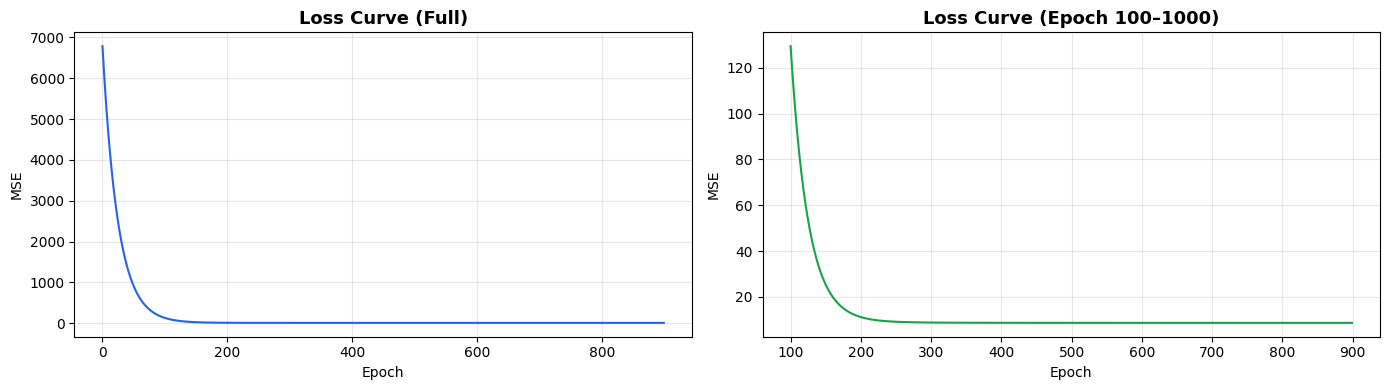


Loss curve disimpan → loss_curve.png


In [7]:
# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------
save_dir = "preprocessed"
train_df = pd.read_csv(os.path.join(save_dir, "train.csv"))
test_df  = pd.read_csv(os.path.join(save_dir, "test.csv"))

feature_cols = ["bias", "TAVG", "TN", "SS", "FF_AVG", "RR", "bulan_sin", "bulan_cos"]

X_train = train_df[feature_cols].values
y_train = train_df["RH_AVG"].values
X_test  = test_df[feature_cols].values
y_test  = test_df["RH_AVG"].values

n_train = X_train.shape[0]

# ----------------------------------------------------------
# HYPERPARAMETER
# ----------------------------------------------------------
learning_rate = 0.01
n_epochs      = 900

# ----------------------------------------------------------
# INISIALISASI BOBOT
# ----------------------------------------------------------
w = np.zeros(X_train.shape[1])   # [w0..w7]

# ----------------------------------------------------------
# GRADIENT DESCENT
# ----------------------------------------------------------
loss_history = []

for epoch in range(n_epochs):
    y_pred   = X_train @ w
    error    = y_pred - y_train
    mse_val  = (1 / n_train) * np.sum(error ** 2)
    loss_history.append(mse_val)
    gradient = (2 / n_train) * (X_train.T @ error)
    w        = w - learning_rate * gradient

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | MSE: {mse_val:.4f}")

# ----------------------------------------------------------
# HASIL BOBOT
# ----------------------------------------------------------
print("\n=== BOBOT AKHIR ===")
labels = ["w0 (bias)", "w1 (TAVG)", "w2 (TN)", "w3 (SS)", "w4 (FF_AVG)", "w5 (RR)", "w6 (bulan_sin)", "w7 (bulan_cos)"]
for name, val in zip(labels, w):
    print(f"  {name}: {val:.6f}")

# ----------------------------------------------------------
# EVALUASI
# ----------------------------------------------------------
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

y_pred_train = X_train @ w
y_pred_test  = X_test  @ w

print("\n=== EVALUASI ===")
print(f"{'Metric':<8} {'Train':>10} {'Test':>10}")
print("-" * 30)
print(f"{'MSE':<8} {mse(y_train, y_pred_train):>10.4f} {mse(y_test, y_pred_test):>10.4f}")
print(f"{'RMSE':<8} {rmse(y_train, y_pred_train):>10.4f} {rmse(y_test, y_pred_test):>10.4f}")
print(f"{'MAE':<8} {mae(y_train, y_pred_train):>10.4f} {mae(y_test, y_pred_test):>10.4f}")
print(f"{'R²':<8} {r2(y_train, y_pred_train):>10.4f} {r2(y_test, y_pred_test):>10.4f}")

# ----------------------------------------------------------
# LOSS CURVE
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_history, color="#2563eb", linewidth=1.5)
axes[0].set_title("Loss Curve (Full)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(100, n_epochs), loss_history[100:], color="#16a34a", linewidth=1.5)
axes[1].set_title("Loss Curve (Epoch 100–1000)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nLoss curve disimpan → loss_curve.png")

## Step 7 — Model Evaluation

The trained model is evaluated using appropriate regression metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²).

These metrics are used to measure how well the model predicts the target variable.

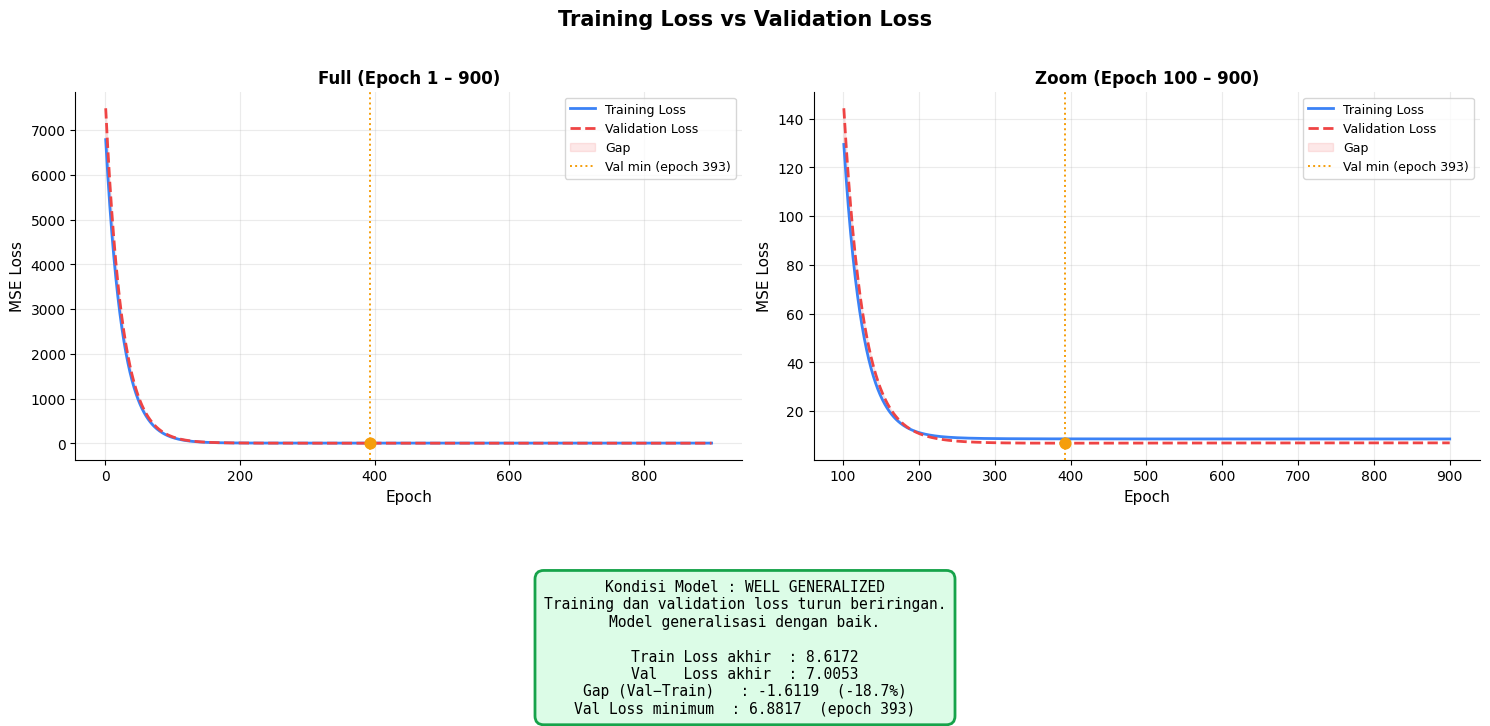


Kondisi Model : WELL GENERALIZED
Plot disimpan → loss_analysis.png


In [8]:
# ----------------------------------------------------------
# REKONSTRUKSI LOSS PER EPOCH
# ----------------------------------------------------------
w_temp           = np.zeros(X_train.shape[1])
loss_train_curve = []
loss_val_curve   = []
n_test           = X_test.shape[0]

for epoch in range(n_epochs):
    yp_tr  = X_train @ w_temp
    err_tr = yp_tr - y_train
    loss_train_curve.append((1 / n_train) * np.sum(err_tr ** 2))

    yp_val  = X_test @ w_temp
    err_val = yp_val - y_test
    loss_val_curve.append((1 / n_test) * np.sum(err_val ** 2))

    grad   = (2 / n_train) * (X_train.T @ err_tr)
    w_temp = w_temp - learning_rate * grad

loss_train_arr = np.array(loss_train_curve)
loss_val_arr   = np.array(loss_val_curve)
epochs         = np.arange(1, n_epochs + 1)

# ----------------------------------------------------------
# DETEKSI KONDISI MODEL
# ----------------------------------------------------------
final_train = loss_train_arr[-1]
final_val   = loss_val_arr[-1]
gap         = final_val - final_train
gap_ratio   = gap / final_train

val_min_idx  = np.argmin(loss_val_arr)
val_min      = loss_val_arr[val_min_idx]
val_end      = loss_val_arr[-1]
overfit_rise = (val_end - val_min) / val_min   # seberapa naik val loss setelah titik terbaik

if overfit_rise > 0.05 and val_min_idx < n_epochs - 50:
    kondisi      = "OVERFITTING"
    kondisi_desc = "Validation loss naik kembali setelah titik minimum.\nModel terlalu hafal data train."
    warna_box    = "#fee2e2"
    warna_border = "#dc2626"
elif gap_ratio > 0.25:
    kondisi      = "BAD GENERALIZATION"
    kondisi_desc = "Gap training vs validation loss terlalu besar.\nModel kurang mampu generalisasi ke data baru."
    warna_box    = "#fef9c3"
    warna_border = "#ca8a04"
else:
    kondisi      = "WELL GENERALIZED"
    kondisi_desc = "Training dan validation loss turun beriringan.\nModel generalisasi dengan baik."
    warna_box    = "#dcfce7"
    warna_border = "#16a34a"

# ----------------------------------------------------------
# PLOT
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Training Loss vs Validation Loss", fontsize=15, fontweight="bold", y=1.02)

for ax, start, subtitle in zip(axes,
                                [0, 100],
                                ["Full (Epoch 1 – {})".format(n_epochs),
                                 "Zoom (Epoch 100 – {})".format(n_epochs)]):
    sl = slice(start, None)
    ep = epochs[sl]

    ax.plot(ep, loss_train_arr[sl], color="#3b82f6", linewidth=2,   label="Training Loss",   zorder=3)
    ax.plot(ep, loss_val_arr[sl],   color="#ef4444", linewidth=2,   label="Validation Loss", zorder=3, linestyle="--")

    # Area gap
    ax.fill_between(ep, loss_train_arr[sl], loss_val_arr[sl],
                    where=(loss_val_arr[sl] >= loss_train_arr[sl]),
                    alpha=0.12, color="#ef4444", label="Gap")

    # Titik minimum validation loss
    if start <= val_min_idx:
        ax.axvline(val_min_idx + 1, color="#f59e0b", linewidth=1.4,
                   linestyle=":", label=f"Val min (epoch {val_min_idx+1})", zorder=4)
        ax.scatter(val_min_idx + 1, val_min, color="#f59e0b", s=60, zorder=5)

    ax.set_title(subtitle, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel("MSE Loss", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

# ----------------------------------------------------------
# ANNOTATION KONDISI MODEL
# ----------------------------------------------------------
bbox_props = dict(boxstyle="round,pad=0.6", facecolor=warna_box,
                  edgecolor=warna_border, linewidth=2)

annotation = (
    f"Kondisi Model : {kondisi}\n"
    f"{kondisi_desc}\n\n"
    f"Train Loss akhir  : {final_train:.4f}\n"
    f"Val   Loss akhir  : {final_val:.4f}\n"
    f"Gap (Val−Train)   : {gap:.4f}  ({gap_ratio*100:.1f}%)\n"
    f"Val Loss minimum  : {val_min:.4f}  (epoch {val_min_idx+1})"
)

fig.text(0.5, -0.12, annotation, ha="center", va="top",
         fontsize=10.5, fontfamily="monospace",
         bbox=bbox_props)

plt.tight_layout()
plt.savefig("loss_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nKondisi Model : {kondisi}")
print(f"Plot disimpan → loss_analysis.png")

## Step 8 — Time Series Cross Validation

Since the dataset used in this project is time-series data (daily weather observations), applying a standard randomized K-Fold Cross Validation would be inappropriate and lead to **data leakage**. In a standard K-Fold, the dataset is shuffled randomly. This means the model might use future weather patterns to predict past events—a scenario that is logically impossible in real-world forecasting.

To properly evaluate the model's robustness and ensure it generalizes well to unseen future data, a **Time Series Cross Validation (Walk-Forward Validation)** is implemented entirely from scratch.

**How it works:**
Instead of randomizing, the data is split sequentially while strictly maintaining the chronological order. The model is trained on historical data and evaluated on the immediate future data using an expanding window approach. The iterations work as follows:

* **Fold 1:** Train on subset 1 $\rightarrow$ Test on subset 2
* **Fold 2:** Train on subsets 1 & 2 $\rightarrow$ Test on subset 3
* **Fold 3:** Train on subsets 1, 2, & 3 $\rightarrow$ Test on subset 4
* *(and so on...)*

By averaging the Mean Squared Error (MSE) across all sequential folds, we can confidently measure the true performance of our Multiple Linear Regression model in a realistic forecasting scenario without violating the timeline of events.

  TIME SERIES K-FOLD CROSS VALIDATION  (K = 6)
Fold      Train    Val        MSE       RMSE        MAE       R²
------------------------------------------------------------
  1          84     84  2523.6880    50.2363    44.6468 -154.4015
  2         168     84   228.1003    15.1030    13.8991  -5.9263
  3         252     84    13.5034     3.6747     2.7119   0.5381
  4         336     84    12.2045     3.4935     2.4120   0.3640
  5         420     84     7.9772     2.8244     2.2612   0.4125
  6         504     84    19.2054     4.3824     3.7506   0.0167
------------------------------------------------------------
  Mean                  467.4465    13.2857    11.6136 -26.4994
  Std                   922.9263    17.0569    15.3276  57.2454


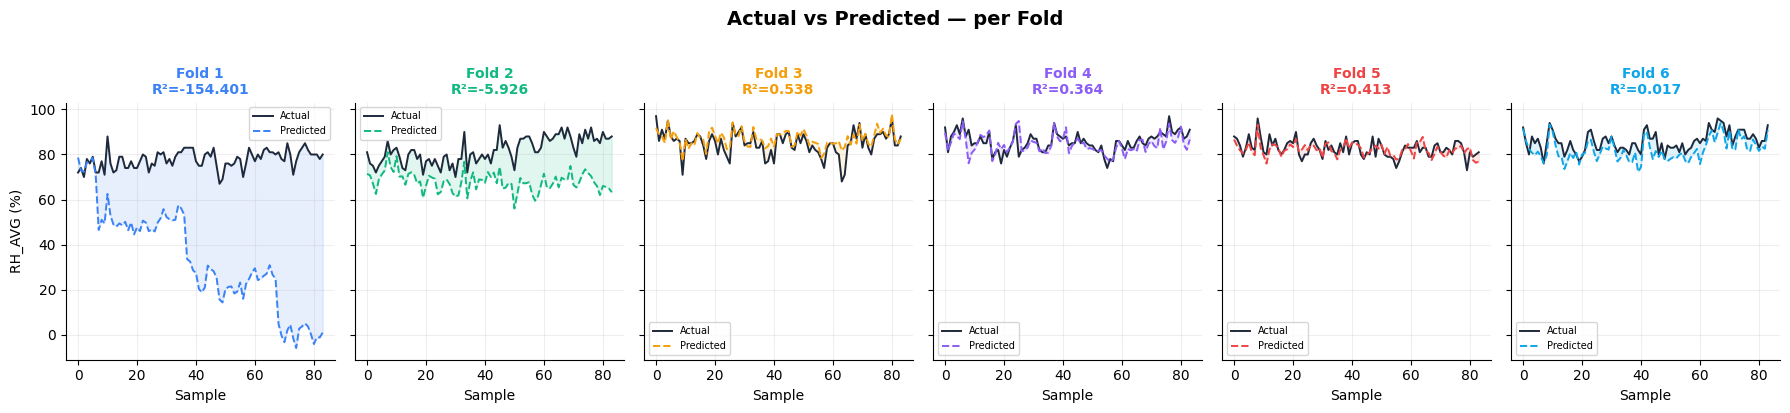

Saved → plot1_actual_vs_predicted.png


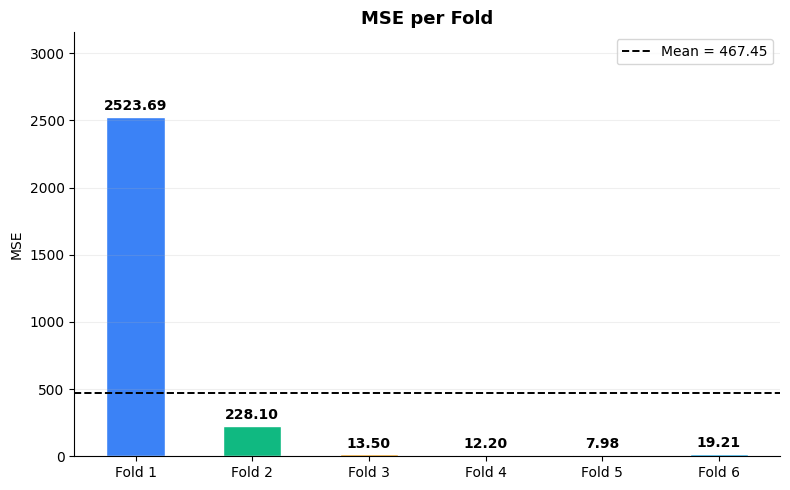

Saved → plot2_mse.png


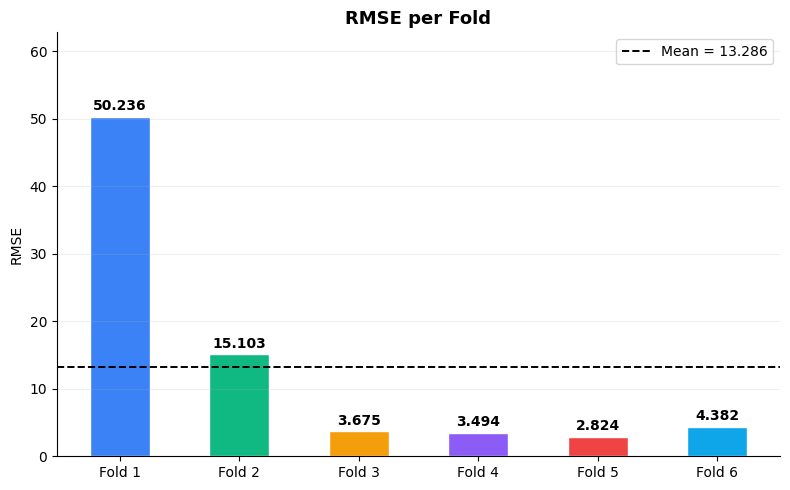

Saved → plot3_rmse.png


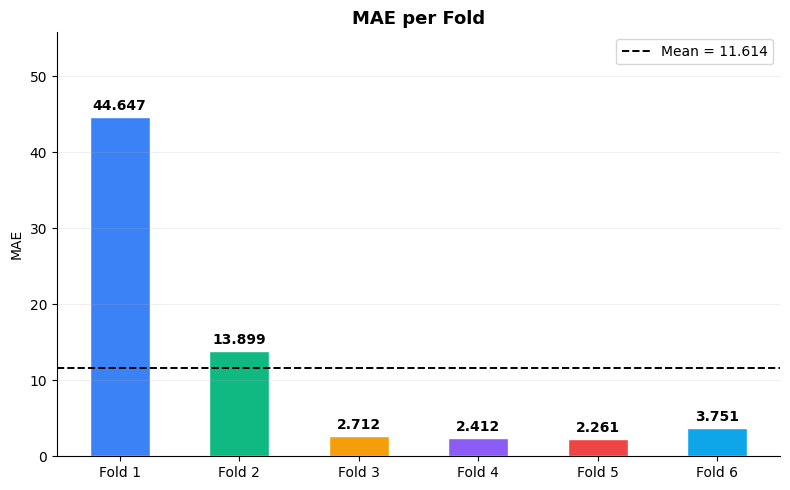

Saved → plot4_mae.png


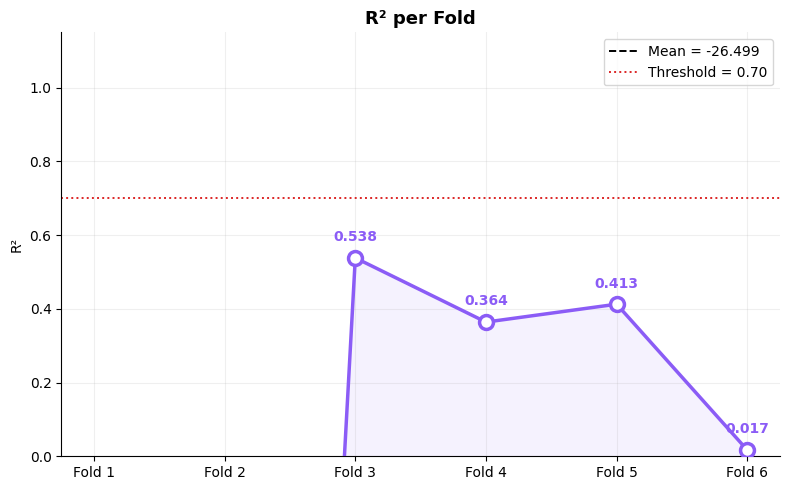

Saved → plot5_r2.png


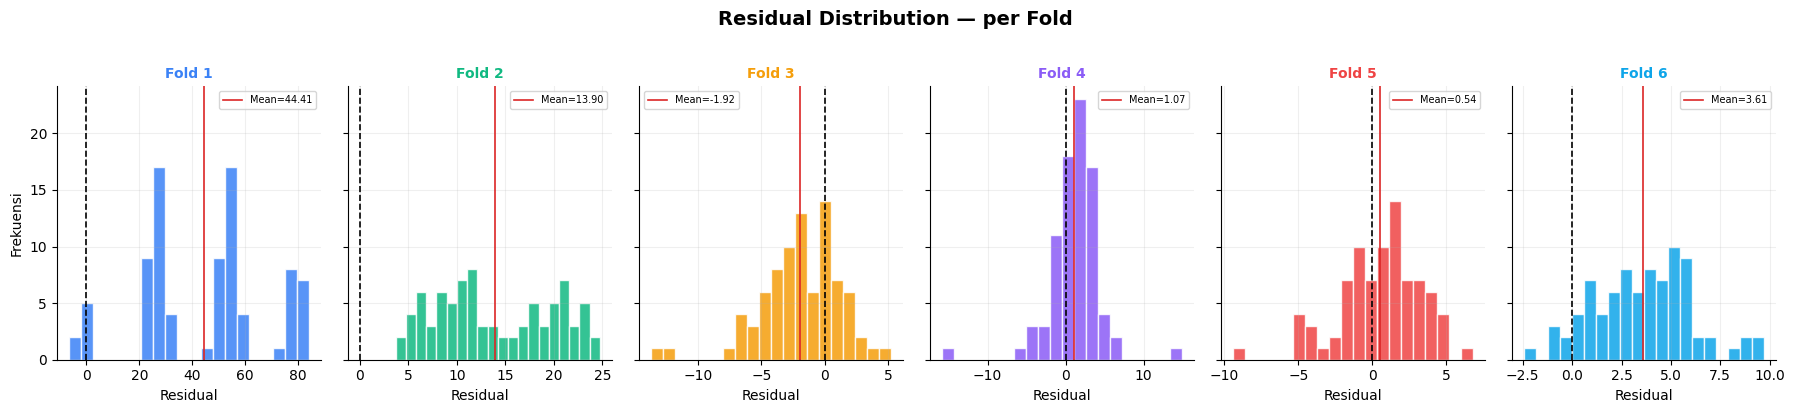

Saved → plot6_residual.png

  ANALISIS RELIABILITAS MODEL
  Mean R²          : -26.4994   ✗ < 0.70
  Std  R²          : 57.2454   ✗ tidak stabil (> 0.05)
  CV   RMSE        : 1.2838   ✗ tidak stabil (> 0.15)
  Semua R² > 0     : ✗ Ada fold dengan R² negatif
------------------------------------------------------------
  Skor Kriteria    : 0 / 4
  Verdict          : TIDAK RELIABLE ✗
  Kesimpulan       : Performa model tidak konsisten antar fold. Perlu perbaikan.


In [9]:
# ============================================================
# CELL 5 — TIME SERIES K-FOLD CROSS VALIDATION (K=6)
# ============================================================

K         = 6
n_samples = X_train_final.shape[0]
fold_size = n_samples // (K + 1)

fold_results = []

print("=" * 60)
print(f"  TIME SERIES K-FOLD CROSS VALIDATION  (K = {K})")
print("=" * 60)
print(f"{'Fold':<6} {'Train':>8} {'Val':>6} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
print("-" * 60)

for i in range(K):
    train_end = (i + 1) * fold_size
    val_end   = (i + 2) * fold_size

    X_tr  = X_train_final[:train_end]
    y_tr  = y_train[:train_end]
    X_val = X_train_final[train_end:val_end]
    y_val = y_train[train_end:val_end]

    w_fold = np.zeros(X_tr.shape[1])
    n_tr   = X_tr.shape[0]

    for _ in range(n_epochs):
        err_fold  = X_tr @ w_fold - y_tr
        grad_fold = (2 / n_tr) * (X_tr.T @ err_fold)
        w_fold    = w_fold - learning_rate * grad_fold

    yp_val  = X_val @ w_fold
    err_val = y_val - yp_val

    mse_f  = np.mean(err_val ** 2)
    rmse_f = np.sqrt(mse_f)
    mae_f  = np.mean(np.abs(err_val))
    ss_res = np.sum(err_val ** 2)
    ss_tot = np.sum((y_val - np.mean(y_val)) ** 2)
    r2_f   = 1 - (ss_res / ss_tot) if ss_tot != 0 else float("nan")

    fold_results.append({
        "fold"   : i + 1,
        "n_train": n_tr,
        "n_val"  : len(y_val),
        "mse"    : mse_f,
        "rmse"   : rmse_f,
        "mae"    : mae_f,
        "r2"     : r2_f,
        "y_val"  : y_val,
        "yp_val" : yp_val,
        "resid"  : err_val,
    })

    print(f"  {i+1:<4} {n_tr:>8} {len(y_val):>6} {mse_f:>10.4f} {rmse_f:>10.4f} {mae_f:>10.4f} {r2_f:>8.4f}")

print("-" * 60)

mse_vals  = np.array([r["mse"]  for r in fold_results])
rmse_vals = np.array([r["rmse"] for r in fold_results])
mae_vals  = np.array([r["mae"]  for r in fold_results])
r2_vals   = np.array([r["r2"]   for r in fold_results])

print(f"  {'Mean':<4} {'':>14} {mse_vals.mean():>10.4f} {rmse_vals.mean():>10.4f} {mae_vals.mean():>10.4f} {r2_vals.mean():>8.4f}")
print(f"  {'Std':<4} {'':>14} {mse_vals.std():>10.4f} {rmse_vals.std():>10.4f} {mae_vals.std():>10.4f} {r2_vals.std():>8.4f}")
print("=" * 60)

# ----------------------------------------------------------
# PALETTE & STYLE
# ----------------------------------------------------------
base_colors = ["#3b82f6", "#10b981", "#f59e0b", "#8b5cf6", "#ef4444", "#0ea5e9", "#f43f5e"]
colors      = base_colors[:K]
folds_label = [f"Fold {r['fold']}" for r in fold_results]

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

# ===========================================================
# IMAGE 1 — Actual vs Predicted (1 panel per fold)
# ===========================================================
fig1, axes1 = plt.subplots(1, K, figsize=(18, 4), sharey=True)
fig1.suptitle("Actual vs Predicted — per Fold", fontsize=14, fontweight="bold", y=1.02)

for ax, r, c in zip(axes1, fold_results, colors):
    x_idx = np.arange(len(r["y_val"]))
    ax.plot(x_idx, r["y_val"],  color="#1e293b", linewidth=1.4, label="Actual")
    ax.plot(x_idx, r["yp_val"], color=c,         linewidth=1.4, linestyle="--", label="Predicted")
    ax.fill_between(x_idx, r["y_val"], r["yp_val"], alpha=0.12, color=c)
    ax.set_title(f"Fold {r['fold']}\nR²={r['r2']:.3f}", fontsize=10, fontweight="bold", color=c)
    ax.set_xlabel("Sample")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7)

axes1[0].set_ylabel("RH_AVG (%)")
fig1.tight_layout()
fig1.savefig("plot1_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot1_actual_vs_predicted.png")


# ===========================================================
# IMAGE 2 — MSE (semua fold dalam 1 grafik)
# ===========================================================
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.bar(folds_label, mse_vals, color=colors, edgecolor="white", width=0.5)
ax2.axhline(mse_vals.mean(), color="black", linestyle="--", linewidth=1.4,
            label=f"Mean = {mse_vals.mean():.2f}")
for i, val in enumerate(mse_vals):
    ax2.text(i, val + mse_vals.max() * 0.02, f"{val:.2f}",
             ha="center", fontsize=10, fontweight="bold")
ax2.set_title("MSE per Fold", fontsize=13, fontweight="bold")
ax2.set_ylabel("MSE")
ax2.set_ylim(0, mse_vals.max() * 1.25)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2, axis="y")
ax2.spines[["top", "right"]].set_visible(False)
fig2.tight_layout()
fig2.savefig("plot2_mse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot2_mse.png")

# ===========================================================
# IMAGE 3 — RMSE (semua fold dalam 1 grafik)
# ===========================================================
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.bar(folds_label, rmse_vals, color=colors, edgecolor="white", width=0.5)
ax3.axhline(rmse_vals.mean(), color="black", linestyle="--", linewidth=1.4,
            label=f"Mean = {rmse_vals.mean():.3f}")
for i, val in enumerate(rmse_vals):
    ax3.text(i, val + rmse_vals.max() * 0.02, f"{val:.3f}",
             ha="center", fontsize=10, fontweight="bold")
ax3.set_title("RMSE per Fold", fontsize=13, fontweight="bold")
ax3.set_ylabel("RMSE")
ax3.set_ylim(0, rmse_vals.max() * 1.25)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.2, axis="y")
ax3.spines[["top", "right"]].set_visible(False)
fig3.tight_layout()
fig3.savefig("plot3_rmse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot3_rmse.png")

# ===========================================================
# IMAGE 4 — MAE (semua fold dalam 1 grafik)
# ===========================================================
fig4, ax4 = plt.subplots(figsize=(8, 5))
ax4.bar(folds_label, mae_vals, color=colors, edgecolor="white", width=0.5)
ax4.axhline(mae_vals.mean(), color="black", linestyle="--", linewidth=1.4,
            label=f"Mean = {mae_vals.mean():.3f}")
for i, val in enumerate(mae_vals):
    ax4.text(i, val + mae_vals.max() * 0.02, f"{val:.3f}",
             ha="center", fontsize=10, fontweight="bold")
ax4.set_title("MAE per Fold", fontsize=13, fontweight="bold")
ax4.set_ylabel("MAE")
ax4.set_ylim(0, mae_vals.max() * 1.25)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.2, axis="y")
ax4.spines[["top", "right"]].set_visible(False)
fig4.tight_layout()
fig4.savefig("plot4_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot4_mae.png")

# ===========================================================
# IMAGE 5 — R² (Line Chart + Markers)
# ===========================================================
fig5, ax5 = plt.subplots(figsize=(8, 5))

ax5.plot(folds_label, r2_vals, color="#8b5cf6", linewidth=2.5,
         marker="o", markersize=10, markerfacecolor="white",
         markeredgecolor="#8b5cf6", markeredgewidth=2.5, zorder=3)

for i, val in enumerate(r2_vals):
    ax5.annotate(f"{val:.3f}",
                 xy=(i, val),
                 xytext=(0, 12),
                 textcoords="offset points",
                 ha="center", fontsize=10, fontweight="bold", color="#8b5cf6")

ax5.axhline(r2_vals.mean(), color="black", linestyle="--", linewidth=1.4,
            label=f"Mean = {r2_vals.mean():.3f}")
ax5.axhline(0.70, color="#dc2626", linestyle=":", linewidth=1.4,
            label="Threshold = 0.70")
ax5.fill_between(folds_label, r2_vals, r2_vals.mean(),
                 alpha=0.08, color="#8b5cf6")

ax5.set_title("R² per Fold", fontsize=13, fontweight="bold")
ax5.set_ylabel("R²")
ax5.set_ylim(0, 1.15)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.2)
ax5.spines[["top", "right"]].set_visible(False)
fig5.tight_layout()
fig5.savefig("plot5_r2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot5_r2.png")


# ===========================================================
# IMAGE 6 — Residual Distribution per Fold
# ===========================================================
fig6, axes6 = plt.subplots(1, K, figsize=(18, 4), sharey=True)
fig6.suptitle("Residual Distribution — per Fold", fontsize=14, fontweight="bold", y=1.02)

for ax, r, c in zip(axes6, fold_results, colors):
    ax.hist(r["resid"], bins=20, color=c, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
    ax.axvline(r["resid"].mean(), color="#dc2626", linestyle="-", linewidth=1.2,
               label=f"Mean={r['resid'].mean():.2f}")
    ax.set_title(f"Fold {r['fold']}", fontsize=10, fontweight="bold", color=c)
    ax.set_xlabel("Residual")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

axes6[0].set_ylabel("Frekuensi")
fig6.tight_layout()
fig6.savefig("plot6_residual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot6_residual.png")

# ----------------------------------------------------------
# ANALISIS RELIABILITAS
# ----------------------------------------------------------
mean_r2    = r2_vals.mean()
std_r2     = r2_vals.std()
mean_rmse  = rmse_vals.mean()
std_rmse   = rmse_vals.std()
cv_rmse    = std_rmse / mean_rmse

r2_ok       = mean_r2   >= 0.70
r2_stable   = std_r2    <= 0.05
rmse_stable = cv_rmse   <= 0.15
all_r2_pos  = np.all(r2_vals > 0)

score = sum([r2_ok, r2_stable, rmse_stable, all_r2_pos])

if score == 4:
    verdict      = "RELIABLE ✓"
    verdict_desc = "Model lulus semua kriteria. Performa konsisten di seluruh fold."
elif score >= 2:
    verdict      = "CUKUP RELIABLE ⚠"
    verdict_desc = "Model cukup stabil namun ada beberapa fold yang perlu diperhatikan."
else:
    verdict      = "TIDAK RELIABLE ✗"
    verdict_desc = "Performa model tidak konsisten antar fold. Perlu perbaikan."

print("\n" + "=" * 60)
print(f"  ANALISIS RELIABILITAS MODEL")
print("=" * 60)
print(f"  Mean R²          : {mean_r2:.4f}   {'✓ >= 0.70'   if r2_ok       else '✗ < 0.70'}")
print(f"  Std  R²          : {std_r2:.4f}   {'✓ stabil'    if r2_stable   else '✗ tidak stabil (> 0.05)'}")
print(f"  CV   RMSE        : {cv_rmse:.4f}   {'✓ stabil'    if rmse_stable else '✗ tidak stabil (> 0.15)'}")
print(f"  Semua R² > 0     : {'✓ Ya'         if all_r2_pos  else '✗ Ada fold dengan R² negatif'}")
print("-" * 60)
print(f"  Skor Kriteria    : {score} / 4")
print(f"  Verdict          : {verdict}")
print(f"  Kesimpulan       : {verdict_desc}")
print("=" * 60)

## Step 9 — Conclusion

This project successfully developed a Multiple Linear Regression (MLR) model entirely from scratch using Gradient Descent to predict the average relative humidity (RH_AVG). By utilizing daily weather data from BMKG and implementing the mathematical algorithm without relying on high-level machine learning libraries, this project demonstrates a fundamental understanding of machine learning mechanics. Furthermore, this study strongly aligns with **SDG 13: Climate Action** by analyzing and predicting crucial climate variables, which is a vital component in climate monitoring and early warning systems.

Based on the overall pipeline, from data preprocessing to advanced evaluation, several key conclusions can be drawn:

* **Algorithm Convergence & Evaluation Discrepancy:** The custom Gradient Descent implementation successfully optimized the model's weights, as evidenced by a consistent decrease in Mean Squared Error (MSE) on the Loss Curve. Initially, utilizing a standard 83/17 train-test split yielded strong performance metrics. However, **the implementation of Time Series Cross-Validation revealed that the model is not entirely reliable across different time periods.** * **Why the Model is Less Reliable over Time:** The discrepancy between the single split and the cross-validation occurs because weather data is highly seasonal and dynamic. The 83/17 split likely tested the model on a specific time frame with relatively stable weather patterns that matched the training data. However, the rigorous time-series cross-validation exposed the model to shifting seasons and complex temporal dynamics. Multiple Linear Regression, by nature, is a strict linear approach and struggles to capture these non-linear, fluctuating seasonal patterns.
* **Feature Insights:** Based on the final weights obtained and the correlations discovered during the Exploratory Data Analysis (EDA) phase, features such as Average Temperature (TAVG), Maximum Temperature (TX), and Sunshine Duration (SS) remain the most significant drivers influencing daily humidity levels. 
* **Future Improvements:** While this linear model serves as an excellent foundational baseline to understand gradient descent, its limitations in time-series forecasting are evident. Future improvements should focus on adopting algorithms capable of handling non-linear relationships and temporal dependencies, such as Polynomial Regression, Tree-based algorithms, or specific time-series models (e.g., ARIMA or Recurrent Neural Networks), which can better capture long-term seasonal climate shifts.

In conclusion, building the entire machine learning pipeline from scratch provided deep, practical insights into both the inner workings of predictive modeling and the critical importance of rigorous evaluation methods (like Time Series CV) in preventing over-optimistic results in real-world forecasting.